<a href="https://colab.research.google.com/github/jennyt14/math-228-phys-insprd-machine-learning/blob/main/first_order_deriv_pinn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This code was given by [this GitHub link](https://github.com/kochlisGit/Physics-Informed-Neural-Network-PINN-Tensorflow/blob/main/TF_PINN.ipynb).

We will use Tensorflow to train a Physics-Informed Neural Network model to solve the equation $\frac{dy}{dx} = y$ with $y(0) = 1$ for interval $x \in [0,2]$. We know the solution is $y = e^x$.

In [1]:
import tensorflow as tf

We generate a uniform dataset with 32 points where each entry is in $[0,2]$.

In [2]:
num_domain = 32
minval = 0
maxval = 2

def generate_uniform_data(num_domain, minval, maxval):
  data_init = tf.random_uniform_initializer(minval=minval, maxval=maxval, seed=0)
  return tf.Variable(data_init(shape=[num_domain, 1]), dtype=tf.float32)

x = generate_uniform_data(num_domain, minval, maxval)
x

<tf.Variable 'Variable:0' shape=(32, 1) dtype=float32, numpy=
array([[0.42203093],
       [1.41202   ],
       [1.6001267 ],
       [1.5415845 ],
       [0.77717733],
       [1.7407188 ],
       [1.616375  ],
       [0.3938818 ],
       [1.6985414 ],
       [1.0803521 ],
       [0.27217007],
       [0.22239375],
       [1.4941943 ],
       [0.39473152],
       [0.71548843],
       [1.0405965 ],
       [0.8522768 ],
       [0.42251015],
       [0.43519688],
       [0.31763887],
       [0.3279183 ],
       [1.9947593 ],
       [0.82617426],
       [0.40056705],
       [1.4406891 ],
       [0.14499807],
       [0.56532216],
       [0.383291  ],
       [0.09421492],
       [1.3626337 ],
       [0.3398428 ],
       [0.82003   ]], dtype=float32)>

To compute the error of the neural network, we are going to compute the derivative of $y$ with respect to $x$. This can be done with Back-Propagation. In Tensorflow, this can be done using a Tensorflow GradientTape.

In [3]:
def jacobian(tape, y, x, i=0, j=0): #computes the derivative of y with respect to x
  if y.shape[1] > 1:
    y = y[:, i : i + 1]

  grads = tape.gradient(y, x)
  return grads[:, j : j + 1]

def pde(tape, x, y): # our given PDE
  dy_x = jacobian(tape, y, x)
  return dy_x - y

def ic_0(x): #initial condition
  return 1

x_ic = tf.constant(0, shape=[1,1])

In [4]:
n_inputs = 1
n_outputs = 1
activation = 'tanh'

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input((n_inputs,)))
model.add(tf.keras.layers.Dense(units=32, activation=activation)) # hidden layer
model.add(tf.keras.layers.Dense(units=32, activation=activation)) # hidden layer
model.add(tf.keras.layers.Dense(units=n_outputs))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
epochs = 5000
learning_rate = 0.0005

#initialize Adam optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

for i in range(epochs + 1):
  with tf.GradientTape() as tape_model:
    with tf.GradientTape() as tape_pde:
      y = model(x, training=True)
      ic_error = model(x_ic, training=True)[0][0] - ic_0(x_ic)
      domain_error = pde(tape_pde, x, y)

    domain_mse = mse = tf.math.reduce_mean(tf.math.square(domain_error), axis=0)
    ic_mse =  tf.math.square(ic_error)
    total_mse = domain_mse + ic_mse

    if i % 1000 == 0:
      print('Epoch: {}\t MSE Loss = {}'.format(i, total_mse.numpy()[0]))

  model_update_gradients = tape_model.gradient(total_mse, model.trainable_variables)
  optimizer.apply_gradients(
    zip(model_update_gradients, model.trainable_variables)
  )

Epoch: 0	 MSE Loss = 1.090235710144043
Epoch: 1000	 MSE Loss = 0.06895911693572998
Epoch: 2000	 MSE Loss = 0.0034757256507873535
Epoch: 3000	 MSE Loss = 0.00023172674991656095
Epoch: 4000	 MSE Loss = 0.00019399380835238844
Epoch: 5000	 MSE Loss = 4.8708836402511224e-05


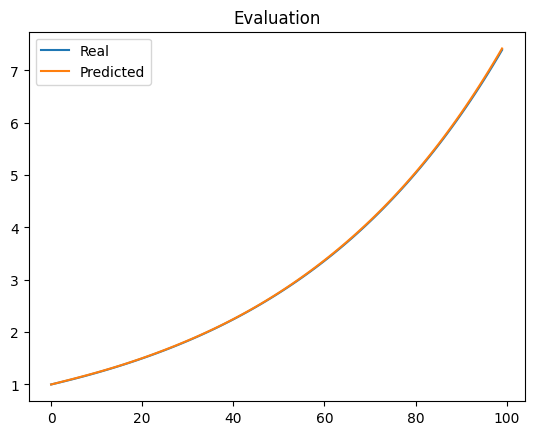

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x_test = np.linspace(0, 2, 100)
y_true = np.exp(x_test)
y_pred = model(x_test)

plt.plot(y_true)
plt.plot(y_pred)
plt.title('Evaluation')
plt.legend(['Real', 'Predicted'])
plt.show()